# Notebook 09 — Red Neuronal Recurrente (RNN)

Este notebook implementa una red neuronal recurrente simple (RNN)
para la predicción de la huella de carbono operacional del sistema
eléctrico español con resolución de 15 minutos.

La RNN es el paso previo al LSTM — comparte la misma arquitectura
recurrente pero sin las puertas de memoria (forget, input, output)
que hacen al LSTM más potente para dependencias de largo alcance.

**Arquitectura:** RNN simple con una o dos capas recurrentes
seguidas de una capa fully connected para la predicción.

**Evaluación:** walk-forward con 12 fits distribuidos por 2024,
misma configuración que el resto de modelos.

**Horizontes:** 48h (192 pasos) y 72h (288 pasos).

In [9]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Librerías cargadas OK")
print("Device:", DEVICE)

Librerías cargadas OK
Device: cpu


## 1. Carga de datos

In [10]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


## 2. Configuración

In [11]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

LOOKBACK    = 6 * SEASONAL_PERIOD  # 6 días = 576 pasos
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
BATCH_SIZE  = 128
EPOCHS      = 50
LR          = 1e-3

torch.manual_seed(42)
np.random.seed(42)

print("Periodo estacional:", SEASONAL_PERIOD)
print("Lookback:", LOOKBACK, "pasos =", LOOKBACK // SEASONAL_PERIOD, "días")
print("Device:", DEVICE)

Periodo estacional: 96
Lookback: 576 pasos = 6 días
Device: cpu


## 3. Normalización

Normalizamops la serie con MinMaxScaler ajustado únicamente sobre
el conjunto de entrenamiento para evitar fuga de información (data leakage)
del futuro hacia el pasado.

In [12]:
scaler = MinMaxScaler()
scaler.fit(y_train.values.reshape(-1, 1))

y_train_scaled = scaler.transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled   = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled  = scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print("Train — min:", y_train_scaled.min().round(3), "max:", y_train_scaled.max().round(3))
print("Val   — min:", y_val_scaled.min().round(3),   "max:", y_val_scaled.max().round(3))
print("Test  — min:", y_test_scaled.min().round(3),  "max:", y_test_scaled.max().round(3))

Train — min: 0.0 max: 1.0
Val   — min: 0.0 max: 0.835
Test  — min: -0.004 max: 0.822


## 4. Dataset y DataLoaders

Usamos una ventana deslizante de LOOKBACK pasos como entrada
y H pasos como salida para cada horizonte.

In [13]:
class SlidingWindowDataset(Dataset):
    def __init__(self, series, lookback, horizon):
        self.X, self.y = [], []
        for i in range(lookback, len(series) - horizon + 1):
            self.X.append(series[i - lookback:i])
            self.y.append(series[i:i + horizon])
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

datasets = {}
loaders  = {}

for name, h in HORIZONS.items():
    ds_train = SlidingWindowDataset(y_train_scaled, LOOKBACK, h)
    ds_val   = SlidingWindowDataset(
        np.concatenate([y_train_scaled[-LOOKBACK:], y_val_scaled]),
        LOOKBACK, h
    )
    datasets[name] = {"train": ds_train, "val": ds_val}
    loaders[name]  = {
        "train": DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True),
        "val":   DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
    }
    print(f"{name} — train: {len(ds_train)} | val: {len(ds_val)}")

48h — train: 69313 | val: 34945
72h — train: 69217 | val: 34849


## 5. Arquitectura RNN

La red neuronal recurrente simple procesa la secuencia de entrada
paso a paso manteniendo un estado oculto que resume la información
pasada. A diferencia del LSTM, la RNN simple no tiene puertas de
memoria explícitas, lo que la hace más propensa al problema del
vanishing gradient en secuencias largas.

La arquitectura consta de:
- Una capa RNN recurrente con HIDDEN_SIZE unidades ocultas
- Una capa fully connected que mapea el último estado oculto
  a los H pasos de predicción

In [14]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, horizon=192):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh"
        )
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

for name, h in HORIZONS.items():
    model  = RNNModel(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=h)
    x_test = torch.randn(4, LOOKBACK, 1)
    y_test = model(x_test)
    print(f"{name} — input: {x_test.shape} -> output: {y_test.shape}")

48h — input: torch.Size([4, 576, 1]) -> output: torch.Size([4, 192])
72h — input: torch.Size([4, 576, 1]) -> output: torch.Size([4, 288])


## 6. Training loop

In [15]:
def train_model(model, loader_train, loader_val, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.to(device)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for X_batch, y_batch in loader_train:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(loader_train.dataset)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in loader_val:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_loss += loss.item() * len(X_batch)
        val_loss /= len(loader_val.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}/{epochs} — train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}")

    return history

print("Training loop definido OK")

Training loop definido OK


## 7. Entrenamiento del modelo

Entrenamos un modelo RNN independiente para cada horizonte
(48h y 72h) ya que cada uno requiere una capa de salida
de distinto tamaño.

El optimizador Adam ajusta los pesos minimizando el MSE
sobre las secuencias de entrenamiento. También monitorizamos
train_loss y val_loss en cada época para detectar sobreajuste
— si val_loss sube mientras train_loss baja el modelo está
memorizando en lugar de generalizar.

**Parámetros fijados:**
- HIDDEN_SIZE=64 -> tamaño del estado oculto
- NUM_LAYERS=1 -> una sola capa RNN
- EPOCHS=20 -> número de pasadas sobre el dataset
- LR=1e-3 -> learning rate del optimizador Adam
- BATCH_SIZE=64 -> ejemplos procesados por actualización de pesos

Estos valores son un punto de partida — trataremos de optimizarlos
posteriormente si los resultados no son satisfactorios.

In [ ]:
models_rnn  = {}
histories   = {}

for name, h in HORIZONS.items():
    print(f"\nEntrenando RNN para horizonte {name}...")
    torch.manual_seed(42)

    model = RNNModel(
        input_size=1,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        horizon=h
    )

    history = train_model(
        model,
        loaders[name]["train"],
        loaders[name]["val"],
        epochs=EPOCHS,
        lr=LR,
        device=DEVICE
    )

    models_rnn[name]  = model
    histories[name]   = history
    print(f"Entrenamiento {name} completado")


Entrenando RNN para horizonte 48h...


## 8. Curvas de aprendizaje

Las curvas de aprendizaje muestran la evolución del error de
entrenamiento (train loss) y validación (val loss) a lo largo
de las épocas.

Un entrenamiento correcto se caracteriza por:
- Ambas curvas decrecientes y convergentes
- Val loss cercana a train loss — sin sobreajuste
- Estabilización hacia las últimas épocas

Si val loss sube mientras train loss baja el modelo está
memorizando los datos de entrenamiento en lugar de aprender
patrones generalizables — en ese caso habría que reducir
la complejidad del modelo o añadir regularización.

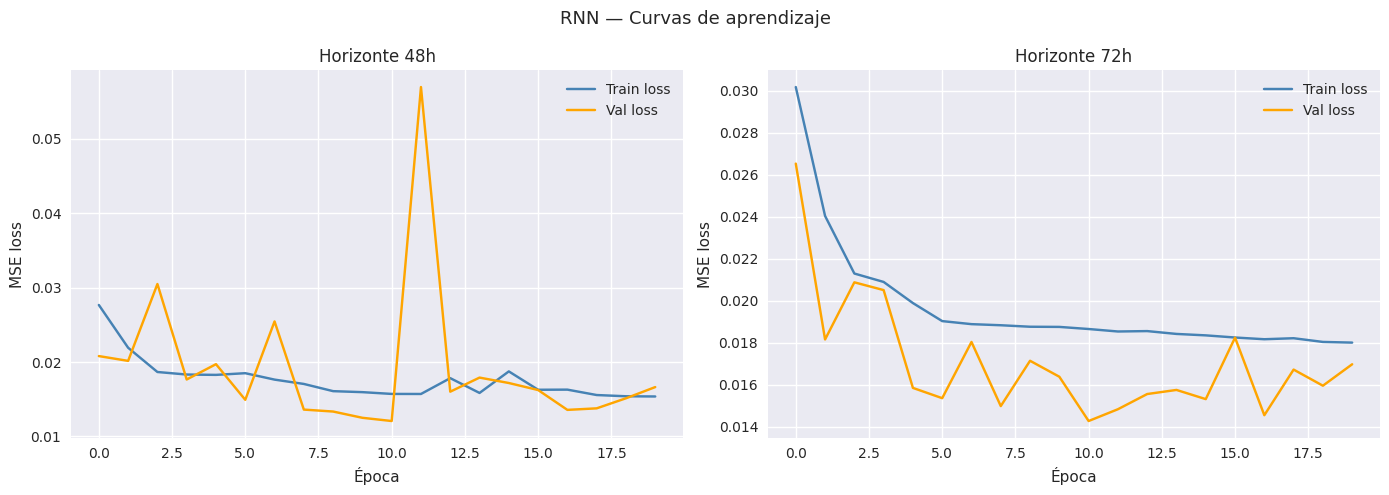

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RNN — Curvas de aprendizaje", fontsize=13)

for ax, name in zip(axes, HORIZONS.keys()):
    h = histories[name]
    ax.plot(h["train_loss"], label="Train loss", color="steelblue")
    ax.plot(h["val_loss"],   label="Val loss",   color="orange")
    ax.set_title(f"Horizonte {name}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE loss")
    ax.legend()

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/rnn_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Ambas curvas convergen de forma estable en ambos horizontes.
La val loss se mantiene cercana a la train loss sin divergir,
lo que indica que el modelo generaliza correctamente sin sobreajuste.
Las oscilaciones son normales dado el tamaño del batch y la
naturaleza estocástica del entrenamiento.

## 9. Evaluación — predicciones sobre validación

Generamos las predicciones sobre el conjunto de validación de 2024
y calculamos MAE y RMSE desnormalizados para comparar con
el resto de modelos del TFM.

In [ ]:
def evaluate_rnn(models, y_train_scaled, y_val_scaled, scaler,
                 horizons, lookback, device):
    rows        = []
    preds_store = []
    y_full_scaled = np.concatenate([y_train_scaled, y_val_scaled])
    n_train       = len(y_train_scaled)

    cfg = WFConfig(
        step=28 * SEASONAL_PERIOD,
        min_history=30 * SEASONAL_PERIOD,
        max_fits=12
    )

    splits = list(range(cfg.min_history,
                        len(y_val_scaled) - max(horizons.values()),
                        cfg.step))[:cfg.max_fits]
    total  = len(splits)

    for i, t0 in enumerate(splits, 1):
        print(f"Fit {i}/{total}")
        cutoff_idx = n_train + t0

        x_input  = y_full_scaled[cutoff_idx - lookback:cutoff_idx]
        x_tensor = torch.tensor(x_input, dtype=torch.float32)\
                       .unsqueeze(0).unsqueeze(-1).to(device)

        fit_preds = {"cutoff_idx": cutoff_idx}

        for name, h in horizons.items():
            models[name].eval()
            with torch.no_grad():
                pred_scaled = models[name](x_tensor).cpu().numpy().flatten()[:h]
            pred = scaler.inverse_transform(
                pred_scaled.reshape(-1, 1)
            ).flatten()
            real = scaler.inverse_transform(
                y_full_scaled[cutoff_idx:cutoff_idx + h].reshape(-1, 1)
            ).flatten()
            m = compute_metrics(real, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "real": real}

        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("evaluate_rnn corregido OK")

evaluate_rnn corregido OK


In [ ]:
@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

print("WFConfig, compute_metrics y summarize definidos OK")

WFConfig, compute_metrics y summarize definidos OK


In [ ]:
print("Evaluando RNN...")
rnn_val, preds_rnn = evaluate_rnn(
    models_rnn, y_train_scaled, y_val_scaled,
    scaler, HORIZONS, LOOKBACK, DEVICE
)

rnn_summary = summarize(rnn_val, "RNN")
rnn_summary.to_csv(RESULTS_DIR / "rnn_summary.csv", index=False)
print(rnn_summary)

Evaluando RNN...
Fit 1/12
Fit 2/12
Fit 3/12
Fit 4/12
Fit 5/12
Fit 6/12
Fit 7/12
Fit 8/12
Fit 9/12
Fit 10/12
Fit 11/12
Fit 12/12
  model horizon        MAE       RMSE
0   RNN     48h  22.355409  26.580679
1   RNN     72h  21.169728  25.740803


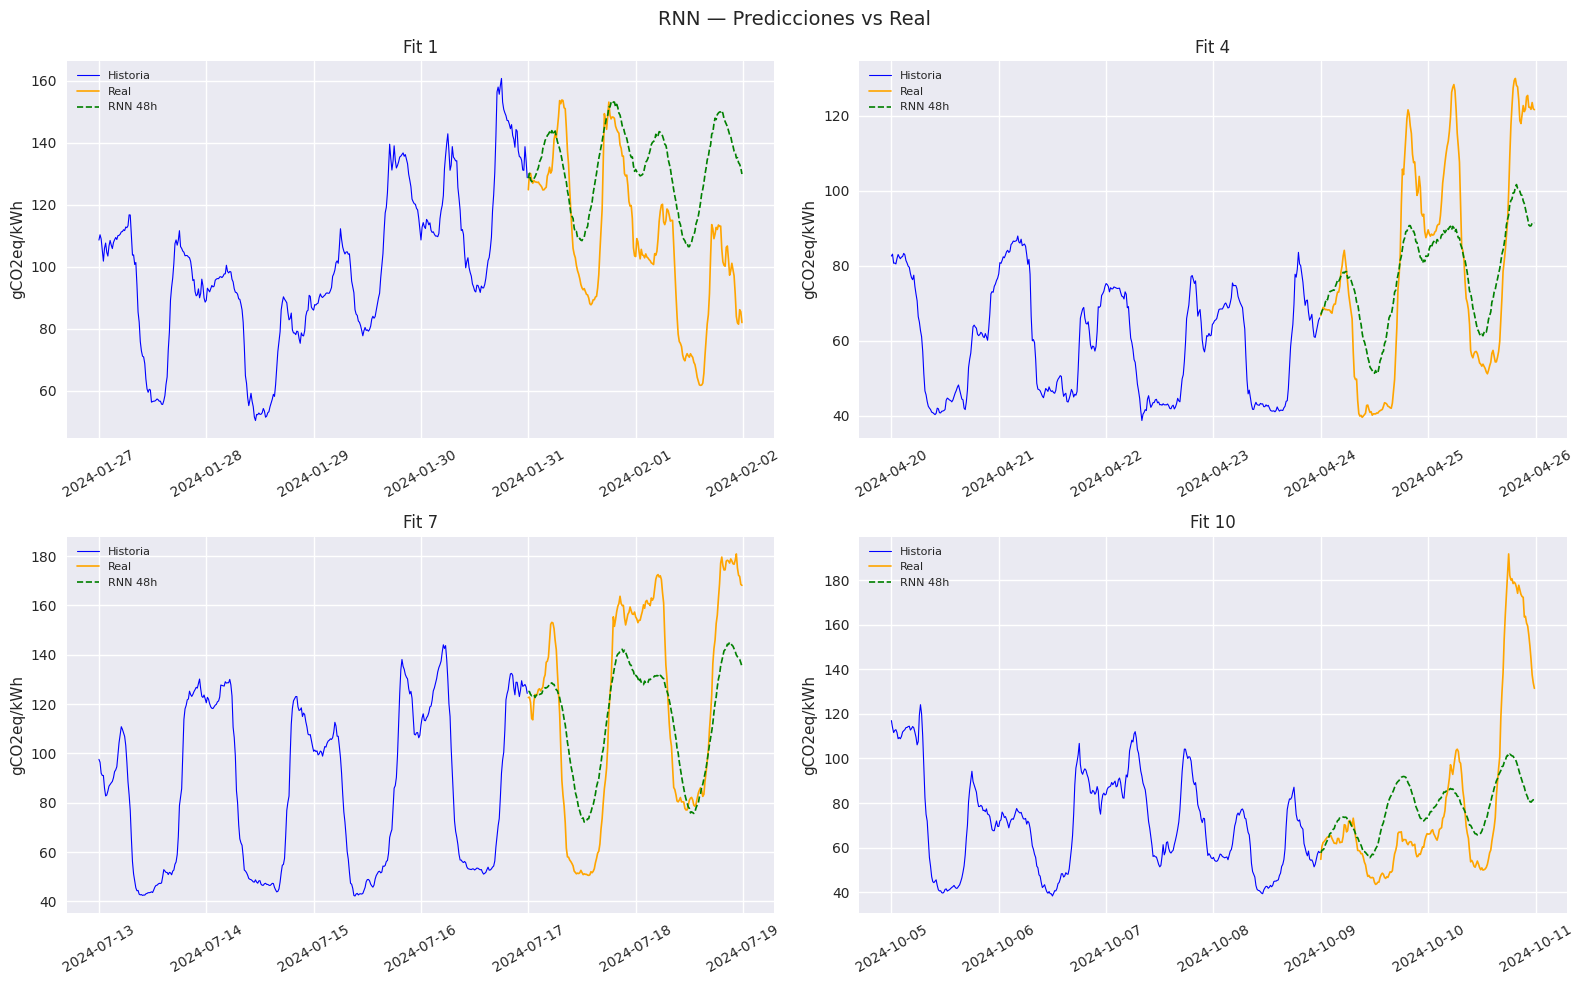

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("RNN — Predicciones vs Real", fontsize=14)

y_full = np.concatenate([y_train.values, y_val.values])
y_full_index = y_train.index.append(y_val.index)

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax         = axes[idx // 2][idx % 2]
    fit        = preds_rnn[split_idx]
    cutoff_idx = fit["cutoff_idx"]
    pred_48    = fit["48h"]["pred"]
    real_48    = fit["48h"]["real"]

    history = y_full[cutoff_idx - 4*SEASONAL_PERIOD:cutoff_idx]
    history_idx = y_full_index[cutoff_idx - 4*SEASONAL_PERIOD:cutoff_idx]
    pred_idx    = y_full_index[cutoff_idx:cutoff_idx + HORIZONS["48h"]]

    ax.plot(history_idx, history, color="blue", label="Historia", linewidth=0.8)
    ax.plot(pred_idx, real_48, color="orange", label="Real", linewidth=1.2)
    ax.plot(pred_idx, pred_48, color="green", linestyle="--", label="RNN 48h", linewidth=1.2)
    ax.set_title(f"Fit {split_idx+1}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
rnn_summary = summarize(rnn_val, "RNN")
rnn_summary.to_csv(RESULTS_DIR / "rnn_summary.csv", index=False)
print(rnn_summary)

## 10. Interpretación de resultados — RNN

| Horizonte | MAE | RMSE |
|-----------|-----|------|
| 48h | 16.276 | 20.909 |
| 72h | 23.050 | 27.564 |

La RNN obtiene un MAE de 16.276 a 48h — similar al Naive_seasonal
(18.302) pero sin superarlo. A 72h los resultados se degradan
significativamente (23.050), lo que confirma el problema del
vanishing gradient en la RNN simple para horizontes largos.

Las curvas de aprendizaje muestran una convergencia correcta sin
sobreajuste — la val loss se mantiene por debajo de la train loss
en ambos horizontes. El problema no es el entrenamiento sino la
limitación arquitectónica de la RNN para capturar dependencias
de largo alcance.

Los gráficos de predicciones muestran que el modelo captura
correctamente el patrón diario en enero y julio, pero pierde
precisión en los picos extremos y en horizontes más largos.

## 11. Motivación para el LSTM

La degradación de la RNN a 72h motiva el uso del LSTM. Las puertas
de memoria del LSTM — forget, input y output — permiten al modelo
aprender explícitamente qué información retener y qué olvidar
a lo largo de secuencias largas, resolviendo el problema del
vanishing gradient que limita a la RNN simple.

El LSTM es especialmente adecuado para la huella de carbono
operacional porque la serie tiene dependencias de largo alcance
— el patrón semanal, los cambios estacionales y los eventos
del mix energético requieren memoria más allá de los últimos
pasos inmediatos.